# OCPM analysis
In this notebook, we analyse the generated OCELs using OCPM and our novel split-tree-mining approach

In [1]:
import pm4py
import pandas as pd
import os, json
from collections import defaultdict
import statistics as st

In [2]:
class Split_tree:
    def __init__(self,root):
        self.root = root
        self.nodes = [root]
        self.leaves = []
        self.splits = 0
    
    

## Combine traces to coherent OCEL

In [3]:
complete_ocel_json = {}
complete_ocel_json["objects"] = []
complete_ocel_json["events"] =[]
o_count = 0
path = "../Output_10/"
json_files = [pos_json for pos_json in os.listdir(path) if pos_json.endswith('.json')]
with open(os.path.join(path,json_files[0])) as init_js:
    json_text = json.load(init_js)
    complete_ocel_json["objectTypes"]= json_text["objectTypes"]
    complete_ocel_json["eventTypes"]= json_text["eventTypes"]

for index, js in enumerate(json_files):
    with open(os.path.join(path, js)) as json_file:
        json_ocel = json.load(json_file)
        o_count += len(json_ocel["objects"])
        complete_ocel_json["objects"] +=(json_ocel["objects"])
        complete_ocel_json["events"]+=(json_ocel["events"])

# Serializing json
json_object = json.dumps(complete_ocel_json)

# Writing to sample.json
with open("OCEL.json", "w") as outfile:
    outfile.write(json_object)

In [4]:
ocel = pm4py.read_ocel2_json("OCEL.json")

In [8]:
ocel.get_summary()


"Object-Centric Event Log (number of events: 5470, number of objects: 2371, number of activities: 10, number of object types: 3, events-objects relationships: 7905)\nActivities occurrences: Counter({'Check Availability': 841, 'Pick Item': 841, 'Split Item': 753, 'Pack Items': 704, 'Store Package': 704, 'Load Package': 704, 'Deliver Package': 704, 'Place Order': 73, 'Send Invoice': 73, 'Receive Payment': 73})\nObject types occurrences (number of objects): Counter({'Item': 1594, 'Package': 704, 'Order': 73})\nUnique activities per object type: Counter({'Item': 5, 'Package': 4, 'Order': 3})\nPlease use <THIS>.get_extended_table() to get a dataframe representation of the events related to the objects."

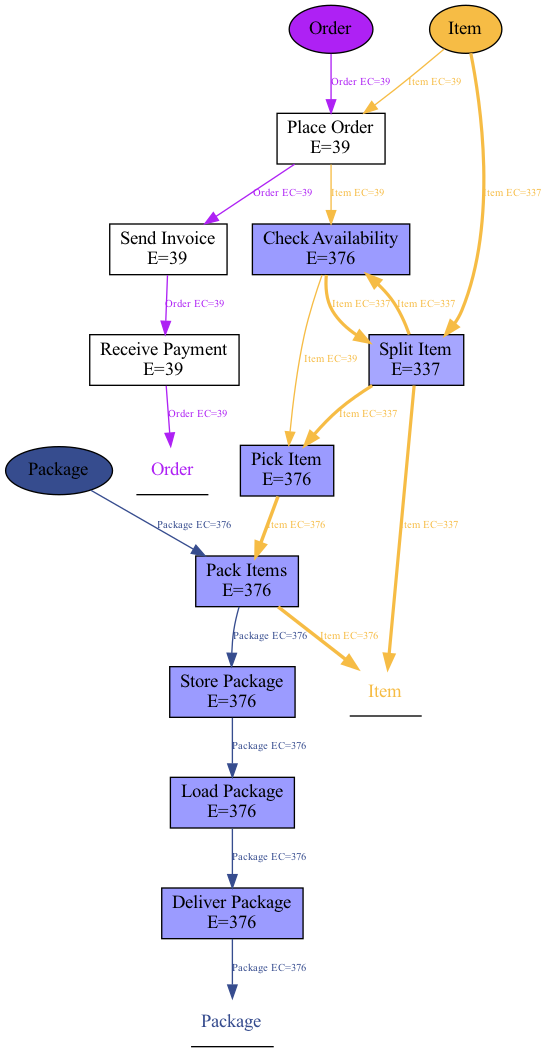

In [7]:
pm4py.view_ocdfg(pm4py.discover_ocdfg(ocel), rankdir='tb')

## Mine Split trees

1. initialize all items as not visited
2. find all roots via order placed
2. initialise graph for each root
3. get list of all split events
4. iterate over splits, marking item as visited and adding them to queue while adding edges


In [30]:
items = ocel.objects[ocel.objects['ocel:type']=="Item"]["ocel:oid"].unique()
order_placed = pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Place Order'])

nested_roots = order_placed.get_extended_table()["ocel:type:Item"].tolist()
roots = []
for nested_root in nested_roots:
    for root in nested_root:
        roots.append(root)

split_df = pm4py.filter_ocel_event_attribute(ocel,'ocel:activity',['Split Item']).get_extended_table()
split_parents = ocel.relations[(ocel.relations["ocel:activity"]=="Split Item") & (ocel.relations["ocel:qualifier"]=="Split of available items for delivery")]
split_trees={}

for root in roots:
    split_trees[root]=(Split_tree(root))

In [31]:
len(roots)

71

In [32]:
for root in roots:
    queue = [root]
    while queue:
        current = queue.pop(0)
        if current in split_parents["ocel:oid"].copy().to_numpy():
            split_id = split_parents[split_parents["ocel:oid"]==current]["ocel:eid"].to_numpy()[0]
            split = split_df[split_df["ocel:eid"]==split_id]["ocel:type:Item"].to_numpy()[0]
            split.remove(current)
            split_trees[root].nodes += split
            queue += split
            split_trees[root].splits += 1
        else:
            split_trees[root].leaves.append(current)


## Analyse Processes
1. order completion
2. mean item lead time

metadata: #num objects, num events, events time?

In [33]:
leaves_sum = 0
for tree in split_trees.values():
    leaves_sum += len(tree.leaves)

In [34]:
leaves_sum

317

In [35]:
ocel.get_extended_table().shape

(2346, 15)

In [36]:
# traceability to packages

In [37]:
ocel.get_extended_table().head()

,ocel:eid,ocel:timestamp,ocel:activity,company,payment_method,checker,spliter,picker,packer,storer,loader,logistics_company,ocel:type:Order,ocel:type:Item,ocel:type:Package
0,e_0_1_company_1,2025-05-21 18:14:12+00:00,Place Order,company_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[order_0],[item_0_0],NaN
1,e_0_2_company_1,2025-05-24 02:46:12+00:00,Send Invoice,company_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[order_0],NaN,NaN
2,e_0_0_4_company_1_0,2025-05-26 08:24:12+00:00,Check Availability,NaN,NaN,S. Wilson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[item_0_0],NaN
3,e_1_1_company_1,2025-05-26 18:14:12+00:00,Place Order,company_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[order_1],[item_1_1],NaN
4,e_0_0_5_company_1_0,2025-05-27 08:13:12+00:00,Split Item,NaN,NaN,NaN,E. Davis,NaN,NaN,NaN,NaN,NaN,NaN,"[item_0_0, item_0_0_2394, item_0_0_4095]",NaN


In [38]:
lead_times = []
partial_lead_times = []
for tree in split_trees.values():
    deliveries = []
    for leave in tree.leaves:
        package = ocel.o2o[(ocel.o2o["ocel:oid_2"]==leave)& (ocel.o2o["ocel:qualifier"]=="Package of item")]["ocel:oid"].values[0]
        package_trace = pm4py.filter_ocel_objects(ocel, [package]).get_extended_table()
        deliveries.append(package_trace[package_trace['ocel:activity']== "Deliver Package"]["ocel:timestamp"].max())
    start_trace = pm4py.filter_ocel_objects(ocel, [tree.root]).get_extended_table()
    start = start_trace[start_trace["ocel:activity"]=="Place Order"]["ocel:timestamp"].min()
    lead_times.append((max(deliveries)-start).days)
    for end in deliveries:
        partial_lead_times.append((end-start).days)

In [39]:
st.mean(lead_times)

26.056338028169016

In [40]:
st.mean(partial_lead_times)

18.514195583596216

In [9]:
pm4py.filter_ocel_object_types(ocel=ocel, obj_types=["Item"])

Object-Centric Event Log (number of events: 3212, number of objects: 1594, number of activities: 5, number of object types: 1, events-objects relationships: 4870)
Activities occurrences: Counter({'Check Availability': 841, 'Pick Item': 841, 'Split Item': 753, 'Pack Items': 704, 'Place Order': 73})
Object types occurrences (number of objects): Counter({'Item': 1594})
Unique activities per object type: Counter({'Item': 5})
Please use <THIS>.get_extended_table() to get a dataframe representation of the events related to the objects.

In [11]:
flat_items = pm4py.ocel.ocel_flattening(ocel, object_type="Item")


In [12]:
flat_items

,ocel:eid,time:timestamp,concept:name,company,payment_method,checker,spliter,picker,packer,storer,loader,logistics_company,case:concept:name,case:ocel:type,case:amount,case:material_id
0,e_0_1_company_1,2025-05-29 09:50:50+00:00,Place Order,company_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,item_0_0,Item,1494.0,0.0
1,e_1_1_company_1,2025-06-02 09:50:50+00:00,Place Order,company_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,item_1_1,Item,1342.0,1.0
2,e_1_1_company_1,2025-06-02 09:50:50+00:00,Place Order,company_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,item_1_2,Item,1470.0,2.0
3,e_1_1_company_1,2025-06-02 09:50:50+00:00,Place Order,company_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,item_1_3,Item,1334.0,3.0
4,e_1_1_company_1,2025-06-02 09:50:50+00:00,Place Order,company_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,item_1_4,Item,1473.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4865,e_77_9_7_company_1_4,2028-03-23 10:20:50+00:00,Pick Item,NaN,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,NaN,item_77_4_7947,Item,147.0,4.0
4866,e_77_9_8_company_1,2028-03-23 10:52:50+00:00,Pack Items,NaN,NaN,NaN,NaN,NaN,J. Williams,NaN,NaN,NaN,item_77_4_7947,Item,147.0,4.0
4867,e_80_8_4_company_1_3,2028-03-28 08:46:50+00:00,Check Availability,NaN,NaN,L. Moore,NaN,NaN,NaN,NaN,NaN,NaN,item_80_3_1164,Item,149.0,3.0
4868,e_80_8_7_company_1_3,2028-03-29 09:05:50+00:00,Pick Item,NaN,NaN,NaN,NaN,L. Moore,NaN,NaN,NaN,NaN,item_80_3_1164,Item,149.0,3.0


In [17]:
flat_items = pm4py.ocel.ocel_flattening(ocel, object_type="Item")
lead_times = []
for item in flat_items["case:concept:name"].unique():
    trace = flat_items[flat_items["case:concept:name"]==item]
    if "Pack Items" in trace["concept:name"].unique():
        package = ocel.o2o[(ocel.o2o["ocel:oid_2"]==item)& (ocel.o2o["ocel:qualifier"]=="Package of item")]["ocel:oid"].values[0]
        package_trace = pm4py.filter_ocel_objects(ocel, [package]).get_extended_table()
        lead_times.append((package_trace[package_trace['ocel:activity']== "Deliver Package"]["ocel:timestamp"].max()-trace["time:timestamp"].min()).days)

st.mean(lead_times)

4.942925089179548

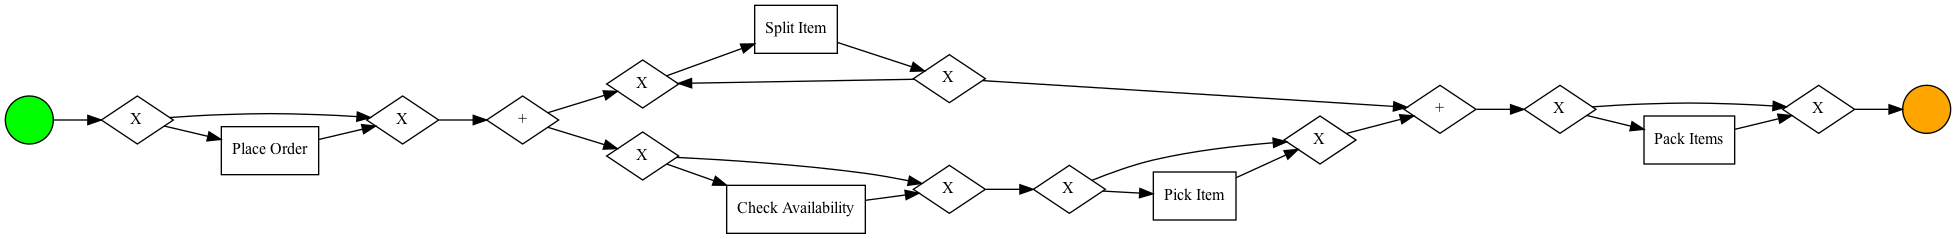

In [19]:
bpmn_graph = pm4py.discover_bpmn_inductive(flat_items)
pm4py.view_bpmn(bpmn_graph)

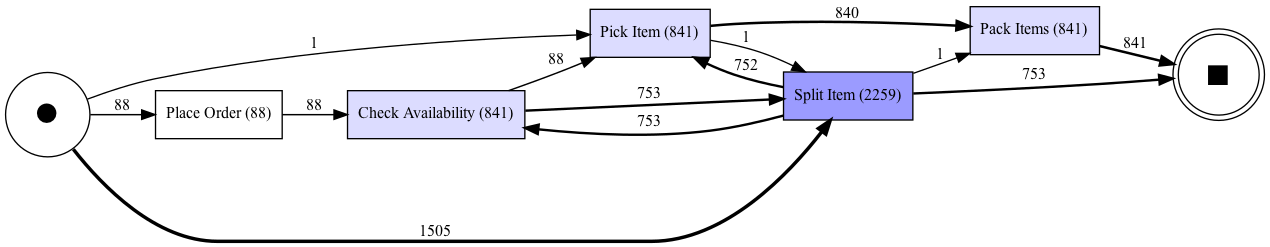

In [20]:
dfg, start, end = pm4py.discover_dfg(flat_items)
pm4py.vis.view_dfg(dfg, start, end)

In [22]:
pm4py.filter_start_activities(
    flat_items,
    ['Pick Item'],
    activity_key='concept:name',
    case_id_key='case:concept:name',
    timestamp_key='time:timestamp'
)

,ocel:eid,time:timestamp,concept:name,company,payment_method,checker,spliter,picker,packer,storer,loader,logistics_company,case:concept:name,case:ocel:type,case:amount,case:material_id,start_timestamp
3759,e_59_6_6_company_1_4,2027-07-22 08:54:50+00:00,Pick Item,NaN,NaN,NaN,NaN,S. Wilson,NaN,NaN,NaN,NaN,item_59_4_2165,Item,163.0,4.0,2027-07-22 08:54:50+00:00
3761,e_59_6_5_company_1_4,2027-07-22 08:55:50+00:00,Split Item,NaN,NaN,NaN,S. Wilson,NaN,NaN,NaN,NaN,NaN,item_59_4_2165,Item,163.0,4.0,2027-07-22 08:55:50+00:00
3764,e_59_6_8_company_1,2027-07-22 09:25:50+00:00,Pack Items,NaN,NaN,NaN,NaN,NaN,O. Garcia,NaN,NaN,NaN,item_59_4_2165,Item,163.0,4.0,2027-07-22 09:25:50+00:00
